# 📑 Tutorials for PyPOTS Imputation Models
## 📀 Preparing the  **Air-Quality** dataset for this tutorial

In [16]:
from benchpots.datasets import preprocess_beijing_air_quality

# Load the dataset with artificially missing values
beijing_air_quality = preprocess_beijing_air_quality(subset="all", rate=0.1, n_steps=24)

2025-03-09 19:37:50 [INFO]: You're using dataset beijing_multisite_air_quality, please cite it properly in your work. You can find its reference information at the below link: 
https://github.com/WenjieDu/TSDB/tree/main/dataset_profiles/beijing_multisite_air_quality
2025-03-09 19:37:50 [INFO]: Dataset beijing_multisite_air_quality has already been downloaded. Processing directly...
2025-03-09 19:37:50 [INFO]: Dataset beijing_multisite_air_quality has already been cached. Loading from cache directly...
2025-03-09 19:37:50 [INFO]: Loaded successfully!
2025-03-09 19:37:50 [INFO]: Current dataframe shape: (35064, 18)
/Users/eigenric/.local/share/virtualenvs/TFG--n4J6ECg/lib/python3.13/site-packages/benchpots/datasets/beijing_multisite_air_quality.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

In [17]:
beijing_air_quality.keys()

dict_keys(['n_steps', 'n_features', 'scaler', 'train_X', 'val_X', 'test_X', 'train_X_ori', 'val_X_ori', 'test_X_ori'])

In [18]:
# Assemble the datasets for training, validating, and testing.

dataset_for_training = {
    "X": beijing_air_quality['train_X'],
}

dataset_for_validating = {
    "X": beijing_air_quality['val_X'],
    "X_ori": beijing_air_quality['val_X_ori'],
}

dataset_for_testing = {
    "X": beijing_air_quality['test_X'],
    "X_ori": beijing_air_quality['test_X_ori']
}


## División en entrenamiento, validación y testing

 The test set
takes data from the first 10 months (2013/03 - 2013/12). The validation set contains data from the following 10 months
(2014/01 - 2014/10). The training set takes the left 28 months (2014/11 - 2017/02). T

In [19]:
dataset_for_testing['X_ori']

array([[[        nan,         nan,         nan, ...,  0.8626411 ,
         -0.07449225, -0.16403657],
        [ 1.3496124 ,  0.67987245, -0.40563312, ...,  0.83304346,
         -0.07449225, -0.01094477],
        [ 1.4417326 ,  0.75492346, -0.3225844 , ...,  0.8256441 ,
         -0.07449225, -0.47022018],
        ...,
        [ 1.6391333 ,  0.9157471 , -0.0734382 , ...,  1.0846231 ,
         -0.07449225, -0.62331194],
        [ 0.7310902 ,  0.7442019 , -0.23953566, ...,  1.0402267 ,
         -0.07449225,  0.21869293],
        [-0.22959304,  0.16523686, -0.36410874, ...,  1.0328273 ,
         -0.07449225, -0.01094477]],

       [[-0.3085533 , -0.67104596, -0.44715747, ...,  1.0254279 ,
         -0.07449225, -0.16403657],
        [-0.216433  , -0.41372818, -0.57173055, ...,  0.6480584 ,
         -0.07449225,  0.6014224 ],
        [-0.5454341 , -0.8640343 , -0.5302062 , ...,  0.5814638 ,
         -0.07449225,  0.907606  ],
        ...,
        [-0.16379282,  0.14379372, -0.69630367, ...,  

In [20]:
dataset_for_testing['X']

array([[[        nan,         nan,         nan, ...,  0.8626411 ,
                 nan, -0.16403657],
        [ 1.3496124 ,  0.67987245, -0.40563312, ...,  0.83304346,
         -0.07449225,         nan],
        [ 1.4417326 ,         nan, -0.3225844 , ...,  0.8256441 ,
         -0.07449225, -0.47022018],
        ...,
        [ 1.6391333 ,  0.9157471 ,         nan, ...,  1.0846231 ,
         -0.07449225, -0.62331194],
        [ 0.7310902 ,  0.7442019 , -0.23953566, ...,  1.0402267 ,
         -0.07449225,  0.21869293],
        [-0.22959304,  0.16523686, -0.36410874, ...,  1.0328273 ,
         -0.07449225, -0.01094477]],

       [[        nan, -0.67104596, -0.44715747, ...,  1.0254279 ,
         -0.07449225, -0.16403657],
        [-0.216433  , -0.41372818, -0.57173055, ...,  0.6480584 ,
         -0.07449225,  0.6014224 ],
        [-0.5454341 , -0.8640343 , -0.5302062 , ...,  0.5814638 ,
         -0.07449225,  0.907606  ],
        ...,
        [-0.16379282,         nan, -0.69630367, ...,  

In [21]:
features = dict()

for i in range(132):
    features[f'f{i}'] = dict()

len(features)

132

In [22]:
import pandas as pd
import numpy as np

# Supongamos que 'dataset_for_testing['X']' es tu numpy array de shape (304, 24, 132)
# Reestructuramos el array para convertirlo en un formato adecuado para series temporales multivariantes
# Transponemos y aplanamos para que tengamos (304 * 24, 132)

X_reshaped = dataset_for_testing['X'].reshape(-1, 132)

# Ahora X_reshaped tiene la forma (304 * 24, 132)

# Creamos un índice para las filas basado en el paso temporal
index = pd.MultiIndex.from_product([range(304), range(24)], names=['Sample', 'Time'])

# Creamos el DataFrame
df = pd.DataFrame(X_reshaped, columns=features, index=index)

# Mostrar las primeras filas del DataFrame
df

f0        f1        f2        f3        f4        f5  \
Sample Time                                                               
0      0          NaN       NaN       NaN       NaN       NaN       NaN   
       1     1.349612  0.679872 -0.405633 -0.332398 -0.131569       NaN   
       2     1.441733       NaN -0.322584 -0.359524 -0.131569  0.695795   
       3     1.520693  0.819253 -0.322584 -0.549400 -0.131569  0.695795   
       4          NaN  0.797810 -0.364109 -0.549400 -0.131569  0.535639   
...               ...       ...       ...       ...       ...       ...   
303    19   -0.927075 -0.703211 -0.613255 -1.091903       NaN -0.051600   
       20   -0.755995 -0.435171 -0.530206       NaN -0.575101 -0.585454   
       21         NaN -0.928364 -0.488682 -0.196773 -0.663807 -0.567659   
       22   -0.992876 -1.078466 -0.654779 -1.254654 -0.841220 -0.033805   
       23   -0.953395 -0.810426 -0.571731 -0.305273 -0.663807 -0.549864   

                   f6        f7        f8        f9  ...      f122      f123  \
Sample Time                                          ...                       
0      0     0.574505 -1.352136  0.897018       NaN  ...  1.116753 -0.280227   
       1     0.482169 -1.372395  0.889591 -0.069919  ...  1.151324       NaN   
       2     0.454468 -1.412912  0.867311 -0.069919  ...  1.220465       NaN   
       3     0.380600 -1.423041  0.859884 -0.069919  ...  1.312654 -0.413696   
       4     0.297497 -1.483816  0.852457       NaN  ...  1.404842 -0.502676   
...               ...       ...       ...       ...  ...       ...       ...   
303    19   -0.164181  0.207763 -1.472132 -0.069919  ... -0.369786 -0.369206   
       20   -0.321152  0.258409 -1.360730 -0.069919  ... -0.565686  0.031203   
       21   -0.376554  0.298926       NaN -0.069919  ... -0.876822 -0.547166   
       22   -0.524291  0.309056 -1.316170 -0.069919  ... -0.969011       NaN   
       23   -0.773597       NaN -1.204767 -0.069919  ... -0.945964       NaN   

                 f124      f125      f126      f127      f128      f129  \
Sample Time                                                               
0      0    -0.740169 -0.274022  1.681782  0.587462 -1.333223  0.862641   
       1    -0.875401  0.713329  1.052236  0.551366       NaN  0.833043   
       2    -0.976826       NaN  0.152884  0.497222 -1.425463  0.825644   
       3    -0.943017       NaN       NaN  0.470149       NaN  0.803446   
       4          NaN  0.120918       NaN  0.343812 -1.486956  0.810845   
...               ...       ...       ...       ...       ...       ...   
303    19    1.626392 -0.372757 -0.746468 -0.332994  0.234855 -1.105600   
       20    1.423544 -0.076552 -0.692507 -0.378114  0.265602 -0.920615   
       21   -0.469705 -0.668963  0.116910 -0.441283  0.275851 -1.127798   
       22   -0.368281 -0.668963  0.026974 -0.621764  0.337344 -1.164795   
       23   -0.334473 -0.668963  0.044961 -0.594692  0.306597 -1.068603   

                 f130      f131  
Sample Time                      
0      0          NaN -0.164037  
       1    -0.074492       NaN  
       2    -0.074492 -0.470220  
       3    -0.074492 -0.852950  
       4          NaN -1.006041  
...               ...       ...  
303    19   -0.074492 -0.010945  
       20   -0.074492 -0.240582  
       21   -0.074492 -0.087491  
       22   -0.074492 -0.010945  
       23   -0.074492 -0.317128  

[7296 rows x 132 columns]

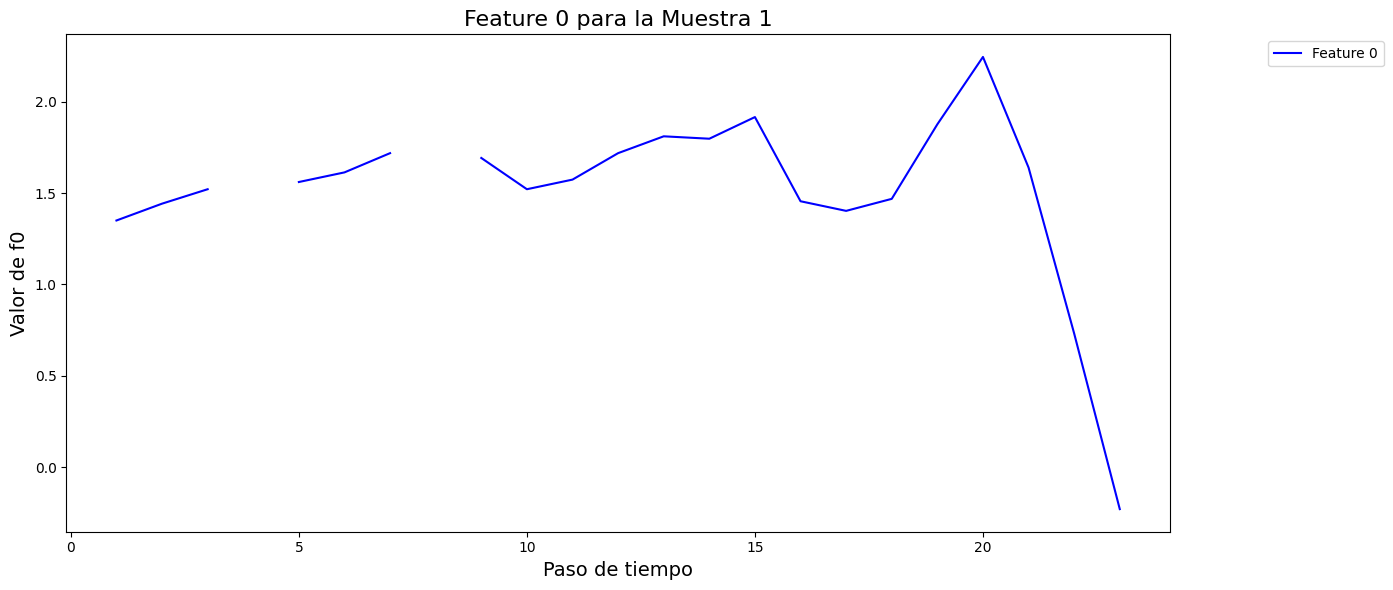

In [23]:
import matplotlib.pyplot as plt

# Seleccionar una muestra específica (por ejemplo, la primera muestra, índice 0)
sample_index = 0
time_steps = range(24)  # 48 pasos de tiempo

# Obtener los datos de la primera muestra para las características específicas
sample_data = df.loc[sample_index, ['f0', 'f1']]

# Crear gráfico para Feature 1
plt.figure(figsize=(14, 6))
if sample_data['f0'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['f0'], label='Feature 0', color='b')
    plt.title(f'Feature 0 para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Valor de f0', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para Feature 0 en la muestra.")



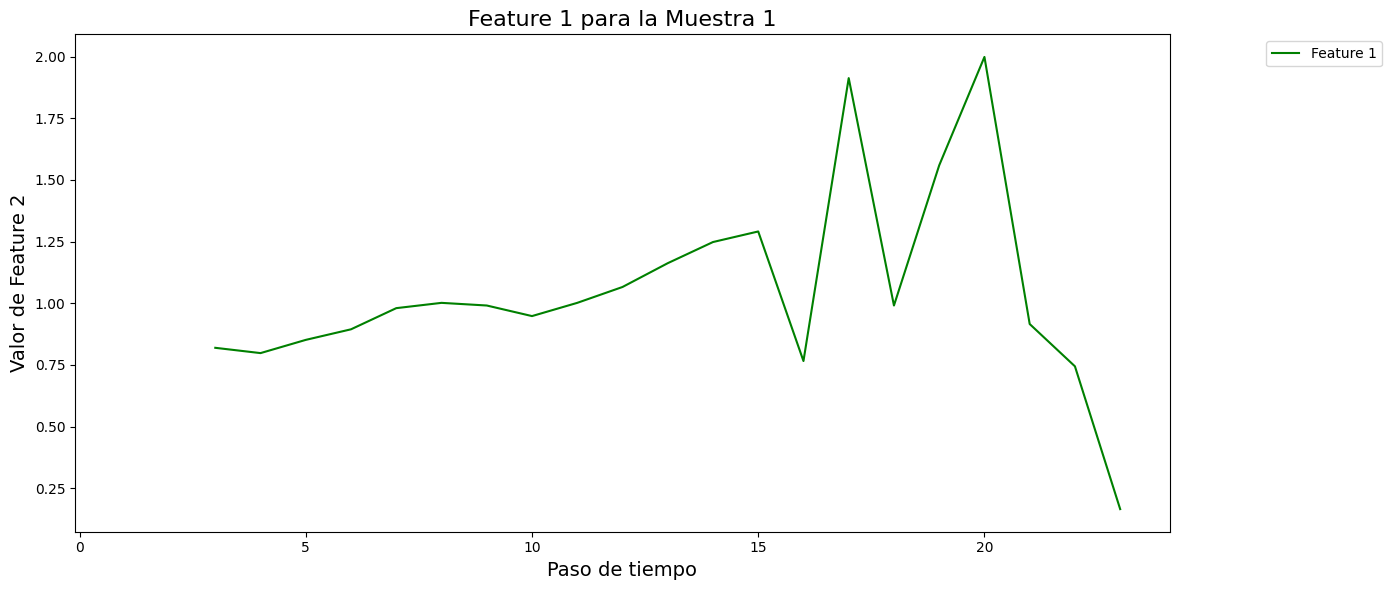

In [24]:
# Crear gráfico para Presión Arterial No Invasiva (NIMAP)
plt.figure(figsize=(14, 6))
if sample_data['f1'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['f1'], label='Feature 1', color='g')
    plt.title(f'Feature 1 para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Valor de Feature 2', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para Feature 1 en la muestra.")

# Mostrar los gráficos
plt.show()


In [25]:
dataset_for_training['X']

array([[[-1.0323558 , -1.1320736 , -0.57173055, ..., -1.7049512 ,
         -0.07449225,  5.7299976 ],
        [        nan, -1.1642385 , -0.57173055, ..., -1.7641464 ,
         -0.07449225,  5.8065434 ],
        [-1.0455158 ,         nan,         nan, ..., -1.8899362 ,
         -0.07449225,  5.194176  ],
        ...,
        [-0.91391534, -1.0784658 , -0.1980113 , ...,         nan,
         -0.07449225,  0.52487653],
        [-0.90075535, -1.0248579 , -0.11496256, ..., -1.5569632 ,
         -0.07449225,  0.29523882],
        [-0.90075535, -1.0248579 , -0.1980113 , ...,         nan,
         -0.07449225,  0.7545142 ]],

       [[-0.9270754 ,         nan,         nan, ...,         nan,
         -0.07449225,         nan],
        [-0.87443525, -0.9069206 ,  0.25875673, ..., -1.5273656 ,
         -0.07449225, -0.62331194],
        [-0.8612752 , -1.0141363 ,  0.46637854, ..., -1.534765  ,
         -0.07449225,  0.21869293],
        ...,
        [ 0.17836834,  0.25100946,  2.00278   , ..., -

In [26]:
beijing_air_quality['n_steps']

24

In [27]:
beijing_air_quality['n_features']

132

In [28]:
import numpy as np

# Copiar el array original
X_imputed_ori = dataset_for_testing['X'].copy()

# Calcular la mediana de cada columna ignorando los NaN
column_medians = np.nanmedian(X_imputed_ori, axis=0)

# Reemplazar los NaN en cada columna con su respectiva mediana
X_imputed = np.where(np.isnan(X_imputed_ori), column_medians, X_imputed_ori)

# Imprimir las medianas calculadas
X_imputed


array([[[-0.24275309, -0.17785352, -0.6547793 , ...,  0.8626411 ,
         -0.07449225, -0.16403657],
        [ 1.3496124 ,  0.67987245, -0.40563312, ...,  0.83304346,
         -0.07449225, -0.47022018],
        [ 1.4417326 , -0.317234  , -0.3225844 , ...,  0.8256441 ,
         -0.07449225, -0.47022018],
        ...,
        [ 1.6391333 ,  0.9157471 , -0.6547793 , ...,  1.0846231 ,
         -0.07449225, -0.62331194],
        [ 0.7310902 ,  0.7442019 , -0.23953566, ...,  1.0402267 ,
         -0.07449225,  0.21869293],
        [-0.22959304,  0.16523686, -0.36410874, ...,  1.0328273 ,
         -0.07449225, -0.01094477]],

       [[-0.24275309, -0.67104596, -0.44715747, ...,  1.0254279 ,
         -0.07449225, -0.16403657],
        [-0.216433  , -0.41372818, -0.57173055, ...,  0.6480584 ,
         -0.07449225,  0.6014224 ],
        [-0.5454341 , -0.8640343 , -0.5302062 , ...,  0.5814638 ,
         -0.07449225,  0.907606  ],
        ...,
        [-0.16379282,  0.0633819 , -0.69630367, ...,  

## 🚀 An example of **SAITS** for imputation

In [29]:
from pypots.optim import Adam
from pypots.imputation import SAITS

# initialize the model
saits = SAITS(
    n_steps=beijing_air_quality['n_steps'],
    n_features=beijing_air_quality['n_features'],
    n_layers=2,
    d_model=256,
    d_ffn=128,
    n_heads=4,
    d_k=64,
    d_v=64,
    dropout=0.1,
    attn_dropout=0.1,
    ##### Esto diferencia al SAIT del modelo Transformer
    diagonal_attention_mask=True,  # otherwise the original self-attention mechanism will be applied
    ORT_weight=1,  # you can adjust the weight values of arguments ORT_weight
    # and MIT_weight to make the SAITS model focus more on one task. Usually you can just leave them to the default values, i.e. 1.
    MIT_weight=1,
    batch_size=32,
    # here we set epochs=10 for a quick demo, you can set it to 100 or more for better performance
    epochs=10,
    # here we set patience=3 to early stop the training if the evaluting loss doesn't decrease for 3 epoches.
    # You can leave it to defualt as None to disable early stopping.
    patience=3,
    # give the optimizer. Different from torch.optim.Optimizer, you don't have to specify model's parameters when
    # initializing pypots.optim.Optimizer. You can also leave it to default. It will initilize an Adam optimizer with lr=0.001.
    optimizer=Adam(lr=1e-3),
    # this num_workers argument is for torch.utils.data.Dataloader. It's the number of subprocesses to use for data loading.
    # Leaving it to default as 0 means data loading will be in the main process, i.e. there won't be subprocesses.
    # You can increase it to >1 if you think your dataloading is a bottleneck to your model training speed
    num_workers=0,
    # just leave it to default as None, PyPOTS will automatically assign the best device for you.
    # Set it as 'cpu' if you don't have CUDA devices. You can also set it to 'cuda:0' or 'cuda:1' if you have multiple CUDA devices, even parallelly on ['cuda:0', 'cuda:1']
    device=None,  
    # set the path for saving tensorboard and trained model files 
    saving_path="tutorial_results/imputation/saits",
    # only save the best model after training finished.
    # You can also set it as "better" to save models performing better ever during training.
    model_saving_strategy="best",
)


2025-03-09 19:37:51 [INFO]: No given device, using default device: cpu
2025-03-09 19:37:51 [INFO]: Model files will be saved to tutorial_results/imputation/saits/20250309_T193751
2025-03-09 19:37:51 [INFO]: Tensorboard file will be saved to tutorial_results/imputation/saits/20250309_T193751/tensorboard
2025-03-09 19:37:51 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 1,558,160


In [30]:
# train the model on the training set, and validate it on the validating set to select the best model for testing in the next step
saits.fit(train_set=dataset_for_training, val_set=dataset_for_validating)


2025-03-09 19:38:00 [INFO]: Epoch 001 - training loss: 0.9681, validation loss: 0.4447
2025-03-09 19:38:03 [INFO]: Epoch 002 - training loss: 0.6378, validation loss: 0.3684
2025-03-09 19:38:06 [INFO]: Epoch 003 - training loss: 0.5447, validation loss: 0.3322
2025-03-09 19:38:09 [INFO]: Epoch 004 - training loss: 0.5034, validation loss: 0.3199
2025-03-09 19:38:11 [INFO]: Epoch 005 - training loss: 0.4789, validation loss: 0.3018
2025-03-09 19:38:13 [INFO]: Epoch 006 - training loss: 0.4544, validation loss: 0.2910
2025-03-09 19:38:16 [INFO]: Epoch 007 - training loss: 0.4358, validation loss: 0.2853
2025-03-09 19:38:18 [INFO]: Epoch 008 - training loss: 0.4264, validation loss: 0.2844
2025-03-09 19:38:21 [INFO]: Epoch 009 - training loss: 0.4206, validation loss: 0.2795
2025-03-09 19:38:23 [INFO]: Epoch 010 - training loss: 0.4117, validation loss: 0.2744
2025-03-09 19:38:23 [INFO]: Finished training. The best model is from epoch#10.
2025-03-09 19:38:23 [INFO]: Saved the model to tut

In [31]:
# the testing stage, impute the originally-missing values and artificially-missing values in the test set

saits_results = saits.predict(dataset_for_testing)
saits_imputation = saits_results["imputation"]


In [32]:
saits_imputation

array([[[ 1.2876257 ,  0.8230436 , -0.5132347 , ...,  0.8626411 ,
         -0.06849748, -0.16403657],
        [ 1.3496124 ,  0.67987245, -0.40563312, ...,  0.83304346,
         -0.07449225, -0.13157223],
        [ 1.4417326 ,  0.81281364, -0.3225844 , ...,  0.8256441 ,
         -0.07449225, -0.47022018],
        ...,
        [ 1.6391333 ,  0.9157471 , -0.31325766, ...,  1.0846231 ,
         -0.07449225, -0.62331194],
        [ 0.7310902 ,  0.7442019 , -0.23953566, ...,  1.0402267 ,
         -0.07449225,  0.21869293],
        [-0.22959304,  0.16523686, -0.36410874, ...,  1.0328273 ,
         -0.07449225, -0.01094477]],

       [[-0.32301605, -0.67104596, -0.44715747, ...,  1.0254279 ,
         -0.07449225, -0.16403657],
        [-0.216433  , -0.41372818, -0.57173055, ...,  0.6480584 ,
         -0.07449225,  0.6014224 ],
        [-0.5454341 , -0.8640343 , -0.5302062 , ...,  0.5814638 ,
         -0.07449225,  0.907606  ],
        ...,
        [-0.16379282, -0.32406506, -0.69630367, ...,  

In [33]:
import pandas as pd
import numpy as np

# Supongamos que 'dataset_for_testing['X']' es tu numpy array de shape (2399, 48, 37)
# Reestructuramos el array para convertirlo en un formato adecuado para series temporales multivariantes
# Transponemos y aplanamos para que tengamos (304 * 24, 132)

X_reshaped = saits_imputation.reshape(-1, 132)

# Ahora X_reshaped tiene la forma (304 * 24, 132)

# Creamos un índice para las filas basado en el paso temporal
index = pd.MultiIndex.from_product([range(304), range(24)], names=['Sample', 'Time'])

# Creamos el DataFrame
df_imputation = pd.DataFrame(X_reshaped, columns=features, index=index)

# Mostrar las primeras filas del DataFrame
df_imputation

f0        f1        f2        f3        f4        f5  \
Sample Time                                                               
0      0     1.287626  0.823044 -0.513235 -0.628689  0.209389  1.107531   
       1     1.349612  0.679872 -0.405633 -0.332398 -0.131569  0.972116   
       2     1.441733  0.812814 -0.322584 -0.359524 -0.131569  0.695795   
       3     1.520693  0.819253 -0.322584 -0.549400 -0.131569  0.695795   
       4     1.146232  0.797810 -0.364109 -0.549400 -0.131569  0.535639   
...               ...       ...       ...       ...       ...       ...   
303    19   -0.927075 -0.703211 -0.613255 -1.091903 -0.857327 -0.051600   
       20   -0.755995 -0.435171 -0.530206 -0.735932 -0.575101 -0.585454   
       21   -0.962161 -0.928364 -0.488682 -0.196773 -0.663807 -0.567659   
       22   -0.992876 -1.078466 -0.654779 -1.254654 -0.841220 -0.033805   
       23   -0.953395 -0.810426 -0.571731 -0.305273 -0.663807 -0.549864   

                   f6        f7        f8        f9  ...      f122      f123  \
Sample Time                                          ...                       
0      0     0.574505 -1.352136  0.897018 -0.012551  ...  1.116753 -0.280227   
       1     0.482169 -1.372395  0.889591 -0.069919  ...  1.151324 -0.382758   
       2     0.454468 -1.412912  0.867311 -0.069919  ...  1.220465 -0.443512   
       3     0.380600 -1.423041  0.859884 -0.069919  ...  1.312654 -0.413696   
       4     0.297497 -1.483816  0.852457 -0.057150  ...  1.404842 -0.502676   
...               ...       ...       ...       ...  ...       ...       ...   
303    19   -0.164181  0.207763 -1.472132 -0.069919  ... -0.369786 -0.369206   
       20   -0.321152  0.258409 -1.360730 -0.069919  ... -0.565686  0.031203   
       21   -0.376554  0.298926 -1.258743 -0.069919  ... -0.876822 -0.547166   
       22   -0.524291  0.309056 -1.316170 -0.069919  ... -0.969011 -0.521206   
       23   -0.773597  0.532545 -1.204767 -0.069919  ... -0.945964 -0.504523   

                 f124      f125      f126      f127      f128      f129  \
Sample Time                                                               
0      0    -0.740169 -0.274022  1.681782  0.587462 -1.333223  0.862641   
       1    -0.875401  0.713329  1.052236  0.551366 -1.532821  0.833043   
       2    -0.976826  0.379908  0.152884  0.497222 -1.425463  0.825644   
       3    -0.943017  0.332667  0.739747  0.470149 -1.577779  0.803446   
       4    -0.543335  0.120918  0.302627  0.343812 -1.486956  0.810845   
...               ...       ...       ...       ...       ...       ...   
303    19    1.626392 -0.372757 -0.746468 -0.332994  0.234855 -1.105600   
       20    1.423544 -0.076552 -0.692507 -0.378114  0.265602 -0.920615   
       21   -0.469705 -0.668963  0.116910 -0.441283  0.275851 -1.127798   
       22   -0.368281 -0.668963  0.026974 -0.621764  0.337344 -1.164795   
       23   -0.334473 -0.668963  0.044961 -0.594692  0.306597 -1.068603   

                 f130      f131  
Sample Time                      
0      0    -0.068497 -0.164037  
       1    -0.074492 -0.131572  
       2    -0.074492 -0.470220  
       3    -0.074492 -0.852950  
       4    -0.094581 -1.006041  
...               ...       ...  
303    19   -0.074492 -0.010945  
       20   -0.074492 -0.240582  
       21   -0.074492 -0.087491  
       22   -0.074492 -0.010945  
       23   -0.074492 -0.317128  

[7296 rows x 132 columns]

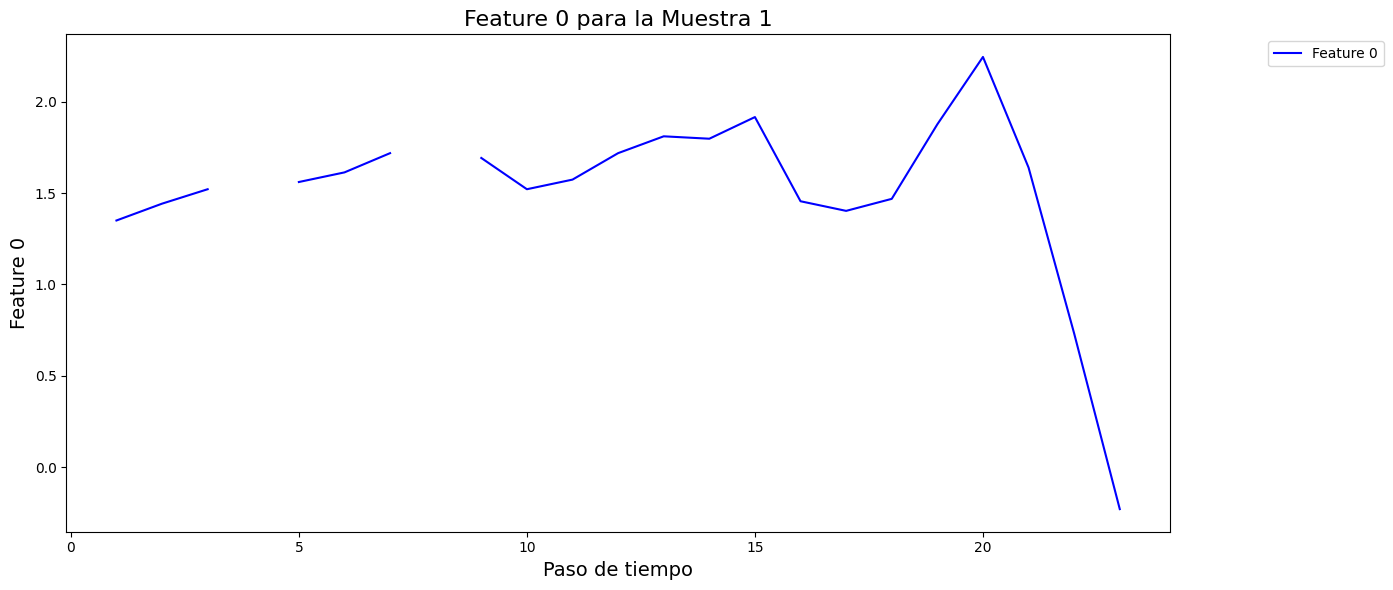

In [34]:
import matplotlib.pyplot as plt

# Seleccionar una muestra específica (por ejemplo, la primera muestra, índice 0)
sample_index = 0
time_steps = range(24)  # 24 pasos de tiempo

# Obtener los datos de la primera muestra para las características específicas
sample_data = df.loc[sample_index, ['f0', 'f1']]

# Crear gráfico para Ritmo Cardíaco (HR)
plt.figure(figsize=(14, 6))
if sample_data['f0'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['f0'], label='Feature 0', color='b')
    plt.title(f'Feature 0 para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Feature 0', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para Feature 0 en la muestra.")



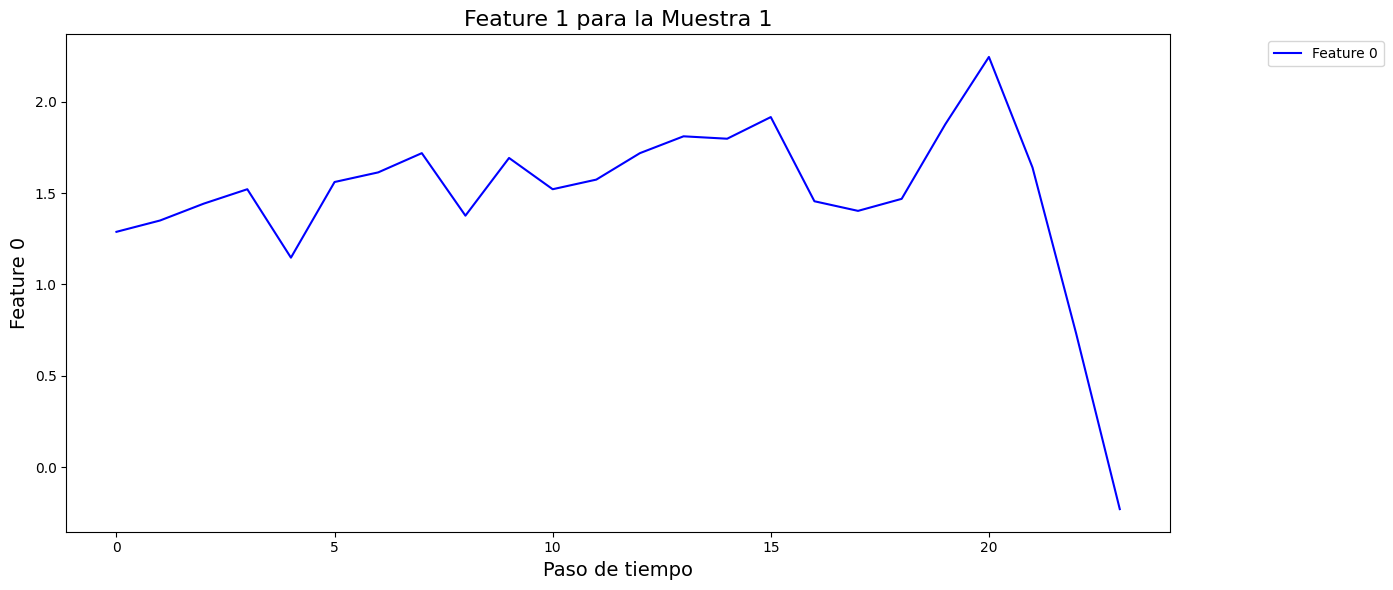

In [35]:
import matplotlib.pyplot as plt

# Seleccionar una muestra específica (por ejemplo, la primera muestra, índice 0)
sample_index = 0
time_steps = range(24)  # 24 pasos de tiempo

# Obtener los datos de la primera muestra para las características específicas
sample_data = df_imputation.loc[sample_index, ['f0', 'f1']]

# Crear gráfico para Ritmo Cardíaco (HR)
plt.figure(figsize=(14, 6))
if sample_data['f0'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['f0'], label='Feature 0', color='b')
    plt.title(f'Feature 1 para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Feature 0', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para Feature 0 en la muestra.")



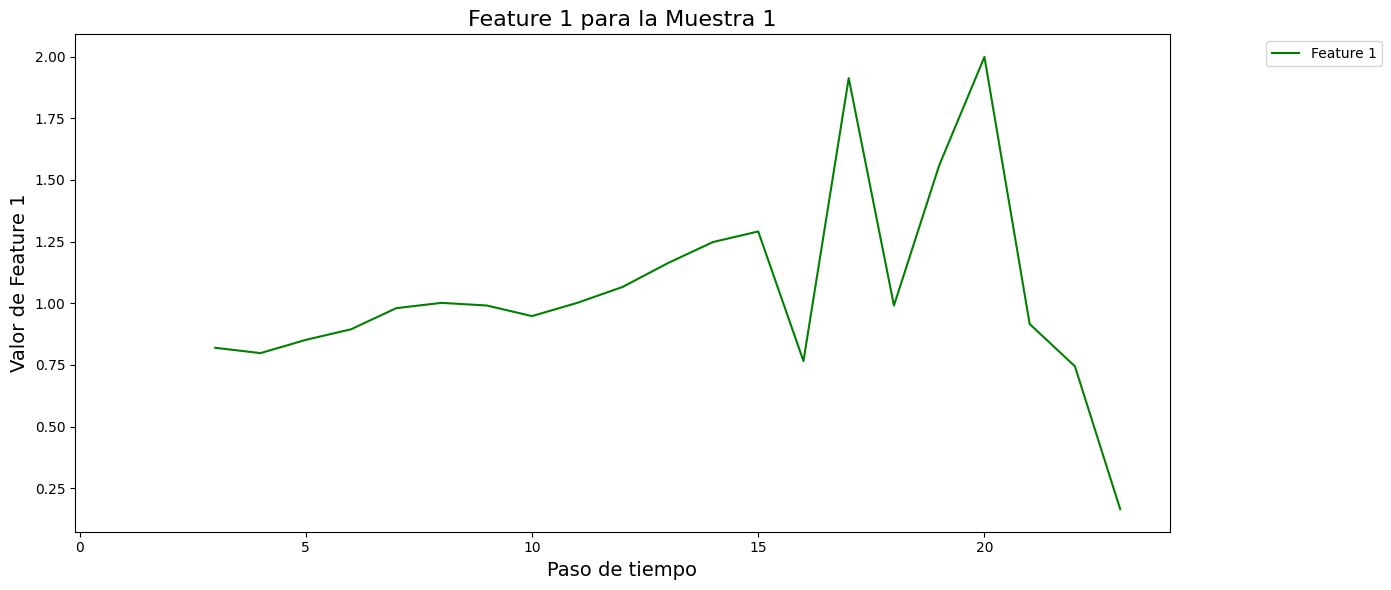

In [36]:
sample_data = df.loc[sample_index, ['f0', 'f1']]

# Crear gráfico para Feature 0
plt.figure(figsize=(14, 6))
if sample_data['f1'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['f1'], label='Feature 1', color='g')
    plt.title(f'Feature 1 para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Valor de Feature 1', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para Feature 1 en la muestra.")

# Mostrar los gráficos
plt.show()



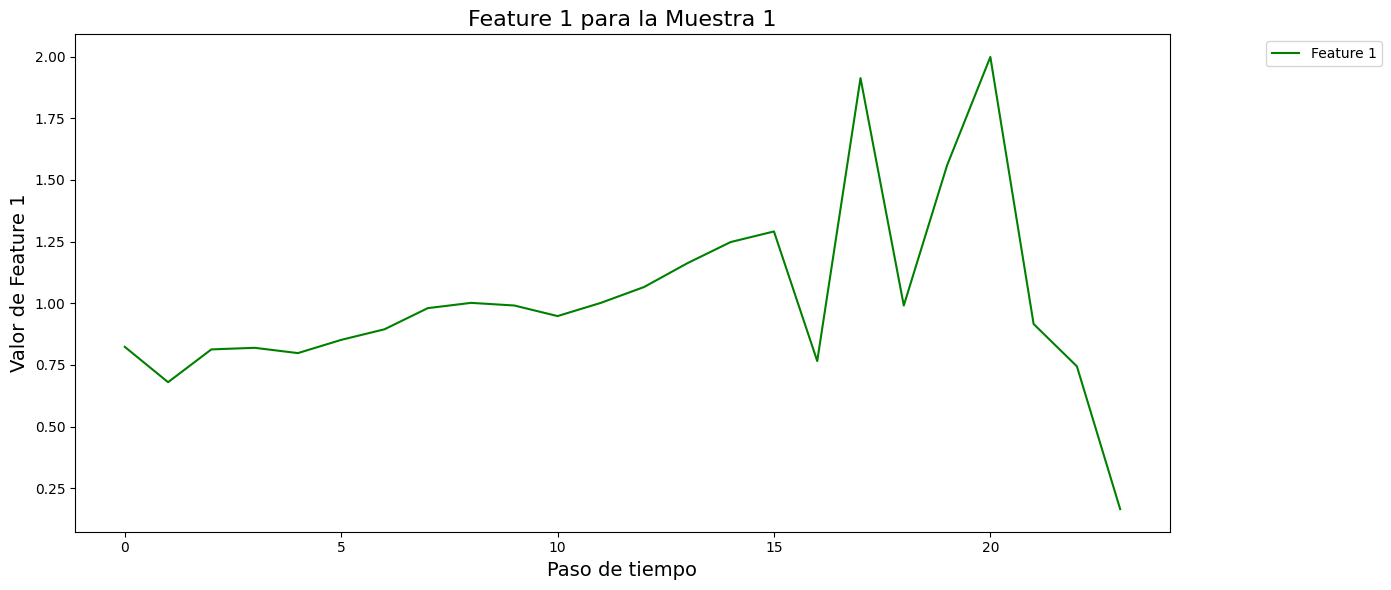

In [37]:
sample_data = df_imputation.loc[sample_index, ['f0', 'f1']]

# Crear gráfico para Presión Arterial No Invasiva (NIMAP)
plt.figure(figsize=(14, 6))
if sample_data['f1'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['f1'], label='Feature 1', color='g')
    plt.title(f'Feature 1 para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Valor de Feature 1', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para Feature 1 en la muestra.")

# Mostrar los gráficos
plt.show()

In [38]:
saits_imputation.shape

(304, 24, 132)

## Comparación de SAITS con métodos baseline¶

In [39]:
from pypots.utils.metrics import calc_mae

beijing_air_quality['test_X_indicating_mask'] = np.isnan(beijing_air_quality['test_X']).astype(int)

# Crear una copia de los datos originales
test_X_ori_fixed = np.copy(beijing_air_quality['test_X_ori'])

# Reemplazar NaNs por 0 (valor constante)
test_X_ori_fixed[np.isnan(test_X_ori_fixed)] = 0

# Verificar si quedan NaNs
num_nans_fixed = np.isnan(test_X_ori_fixed).sum()
print(f"Número de NaNs en test_X_ori después de imputación (con 0): {num_nans_fixed}")

# calculate mean absolute error on the ground truth (artificially-missing values)
# predictions, targets, masks
testing_mae = calc_mae(
    saits_imputation, 
    test_X_ori_fixed, 
    beijing_air_quality['test_X_indicating_mask'],
)
print(f"Testing mean absolute error (MAE): {testing_mae:.4f}")

Número de NaNs en test_X_ori después de imputación (con 0): 0
Testing mean absolute error (MAE): 0.2446


In [40]:
from pypots.utils.metrics import calc_mae

beijing_air_quality['test_X_indicating_mask'] = np.isnan(beijing_air_quality['test_X']).astype(int)

# Crear una copia de los datos originales
test_X_ori_fixed = np.copy(beijing_air_quality['test_X_ori'])

# Reemplazar NaNs por 0 (valor constante)
test_X_ori_fixed[np.isnan(test_X_ori_fixed)] = 0

# Verificar si quedan NaNs
num_nans_fixed = np.isnan(test_X_ori_fixed).sum()
print(f"Número de NaNs en test_X_ori después de imputación (con 0): {num_nans_fixed}")

# calculate mean absolute error on the ground truth (artificially-missing values)
# predictions, targets, masks
testing_mae = calc_mae(
    X_imputed, 
    test_X_ori_fixed, 
    beijing_air_quality['test_X_indicating_mask'],
)
print(f"Testing mean absolute error (MAE): {testing_mae:.4f}")

Número de NaNs en test_X_ori después de imputación (con 0): 0
Testing mean absolute error (MAE): 0.6421
